# ResNet-18 Baseline: Benign vs Standalone Bitstream Classification

Binary classifier on grayscale 1024x1024 images derived from FPGA partial bitstreams.

- **Model:** torchvision ResNet-18, conv1 changed to 1 input channel, fc changed to 1 logit
- **Loss:** BCEWithLogitsLoss
- **Dataset:** 75 benign + standalone with RO >= 4000 (50 samples) = 125 total
- **Split:** stratified 80/20 train/val

## 1. Imports & Configuration

In [1]:
import csv
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image, ImageDraw, ImageFont
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

%matplotlib inline

In [2]:
# --- Paths ---
VAULT_DIR = "/home/sdeheredia/coyote_vault_work/full_dataset_it1_2026-04-01_production"
MANIFEST_PATH = os.path.join(VAULT_DIR, "manifest.csv")
BITSTREAM_DIR = os.path.join(VAULT_DIR, "bitstreams")

SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "runs")
VIZ_DIR = os.path.join(SCRIPT_DIR, "debug_viz")

# --- Hyperparameters ---
IMG_SIZE = 1024
EPOCHS = 50
BATCH_SIZE = 8
LR = 1e-4
SEED = 42
VAL_SPLIT = 0.2
MIN_RO = 4000
NUM_WORKERS = 4
RUN_NAME = None  # auto-generated if None

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Dataset: Manifest Loading & Bitstream-to-Image

In [3]:
def load_manifest(manifest_path=None, min_ro=MIN_RO):
    """Load manifest and filter to benign + standalone with ro_count >= min_ro."""
    manifest_path = manifest_path or MANIFEST_PATH
    samples = []
    with open(manifest_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            class_label = int(row["class_label"])
            ro_count = int(row["ro_count"])
            if class_label == 0:
                samples.append(row)
            elif class_label == 1 and ro_count >= min_ro:
                samples.append(row)
    return samples


def bitstream_to_image(bin_path, img_size=IMG_SIZE, invert=True):
    """Load a raw .bin file and downsample to img_size x img_size uint8 array.

    Uses uniform subsampling via np.linspace (same method as bitstream_viz).
    Inverts pixel values by default (255 - x) for visual consistency.
    """
    data = np.fromfile(bin_path, dtype=np.uint8)
    n = len(data)
    window_size = img_size * img_size

    if n <= window_size:
        window = np.zeros(window_size, dtype=np.uint8)
        window[:n] = data
    else:
        indices = np.linspace(0, n - 1, window_size, dtype=np.int64)
        window = data[indices]

    if invert:
        window = 255 - window

    return window.reshape(img_size, img_size)


class BitstreamDataset(Dataset):
    """PyTorch Dataset for bitstream grayscale images.

    Each sample is a (image_tensor, label) pair where:
    - image_tensor: float32 [1, IMG_SIZE, IMG_SIZE] in [0, 1]
    - label: float32 scalar (0.0 = benign, 1.0 = standalone)
    """

    def __init__(self, sample_list, bitstream_dir=None, img_size=IMG_SIZE):
        self.samples = sample_list
        self.bitstream_dir = bitstream_dir or BITSTREAM_DIR
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]
        bin_path = os.path.join(self.bitstream_dir, row["bitstream_path"])
        img = bitstream_to_image(bin_path, self.img_size)

        tensor = torch.from_numpy(img.astype(np.float32) / 255.0).unsqueeze(0)
        label = torch.tensor(float(row["class_label"]), dtype=torch.float32)

        return tensor, label

    def get_metadata(self, idx):
        return self.samples[idx]

In [4]:
samples = load_manifest()
n_benign = sum(1 for s in samples if int(s["class_label"]) == 0)
n_stand = sum(1 for s in samples if int(s["class_label"]) == 1)
print(f"Dataset: {len(samples)} samples ({n_benign} benign, {n_stand} standalone)")

Dataset: 125 samples (75 benign, 50 standalone)


## 3. Debug Visualization

In [5]:
def get_font(size=14):
    try:
        return ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf", size)
    except (IOError, OSError):
        return ImageFont.load_default()


def make_sample_grid(samples, n_per_class=5):
    """Create a grid with n_per_class benign samples (top) and n_per_class standalone (bottom)."""
    benign = [s for s in samples if int(s["class_label"]) == 0][:n_per_class]
    standalone = [s for s in samples if int(s["class_label"]) == 1][:n_per_class]

    cell = 256
    label_h = 30
    cols = n_per_class
    rows = 2
    width = cols * cell
    height = rows * (cell + label_h) + label_h

    grid = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(grid)
    font = get_font(12)

    draw.text((4, 4), "BENIGN", fill=255, font=font)
    draw.text((4, cell + label_h + 4), "STANDALONE (RO>=4000)", fill=255, font=font)

    for row_idx, row_samples in enumerate([benign, standalone]):
        y_off = label_h + row_idx * (cell + label_h)
        for col_idx, s in enumerate(row_samples):
            bin_path = os.path.join(BITSTREAM_DIR, s["bitstream_path"])
            img = bitstream_to_image(bin_path, IMG_SIZE)
            pil_img = Image.fromarray(img, mode="L").resize((cell, cell), Image.BILINEAR)
            grid.paste(pil_img, (col_idx * cell, y_off))

            label = f"{s['sample_id']} {s['app_name']} ro={s['ro_count']}"
            draw.text(
                (col_idx * cell + 4, y_off + cell + 2),
                label[:30],
                fill=200,
                font=get_font(10),
            )

    return grid

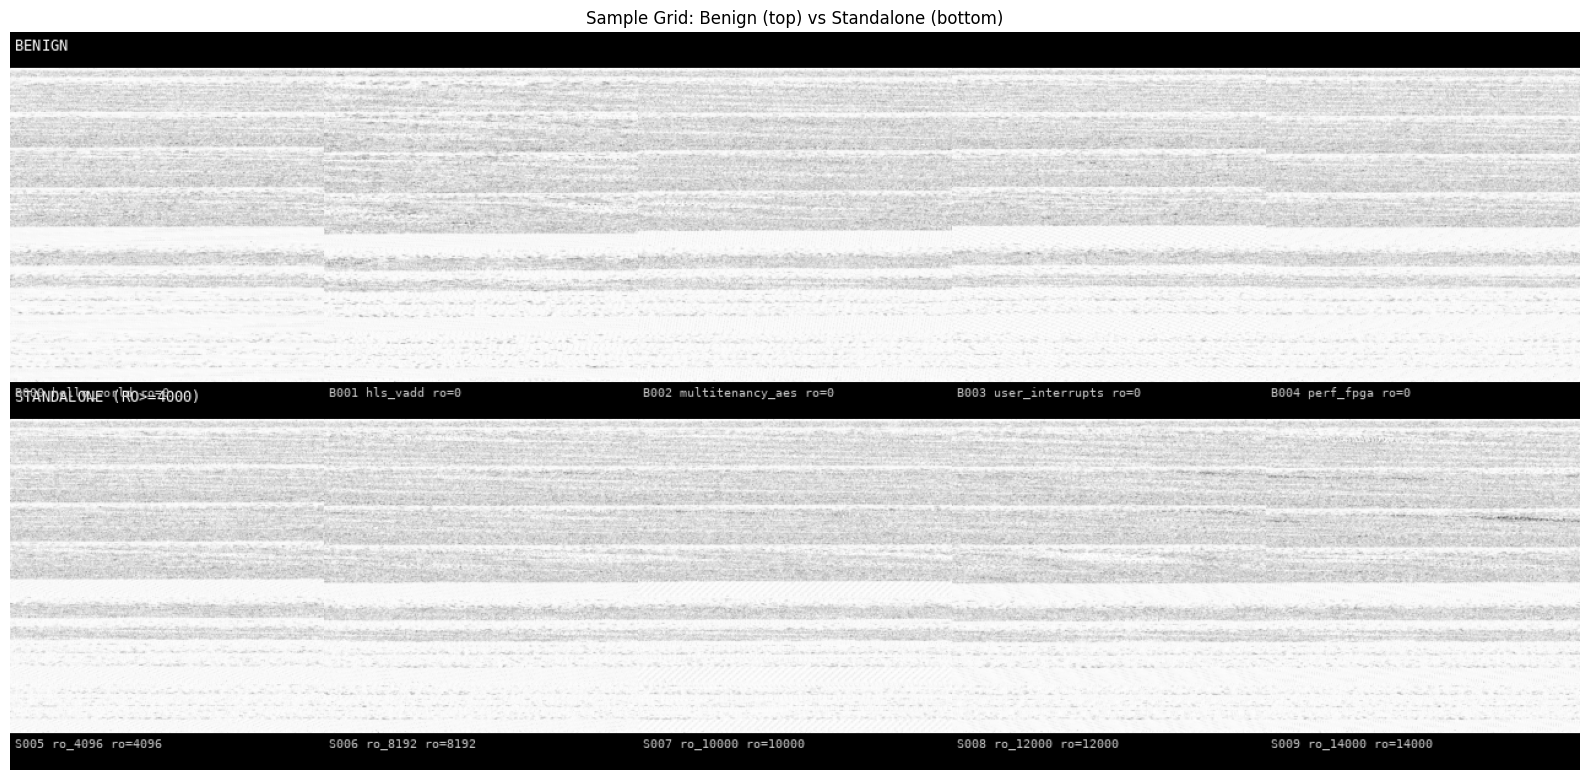

In [6]:
grid = make_sample_grid(samples, n_per_class=5)
plt.figure(figsize=(16, 8))
plt.imshow(np.array(grid), cmap="gray")
plt.axis("off")
plt.title("Sample Grid: Benign (top) vs Standalone (bottom)")
plt.tight_layout()
plt.show()

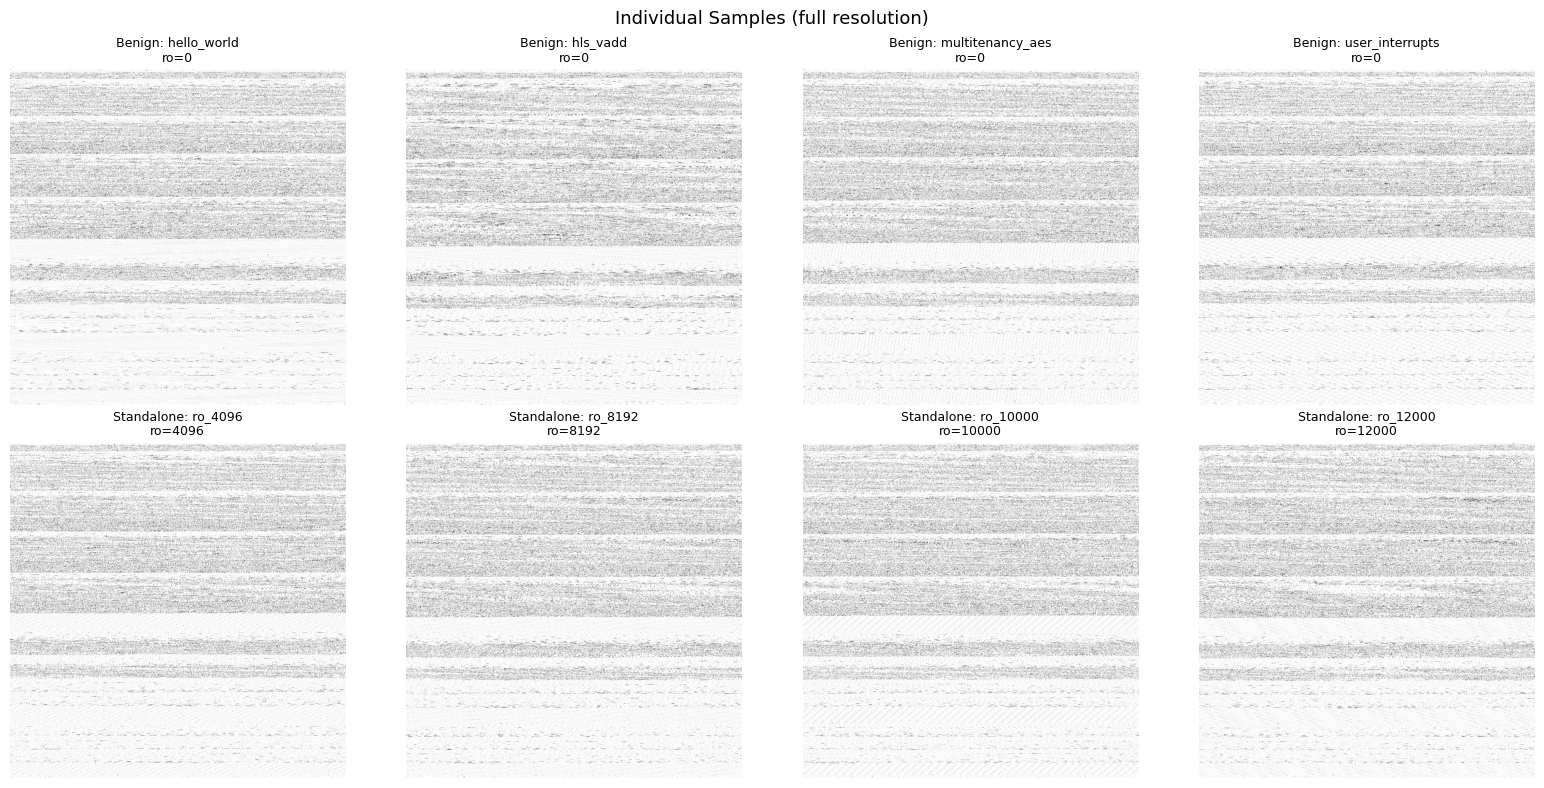

In [7]:
# Show a few individual full-resolution samples
benign_samples = [s for s in samples if int(s["class_label"]) == 0]
standalone_samples = [s for s in samples if int(s["class_label"]) == 1]

n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i in range(n_show):
    s = benign_samples[i]
    img = bitstream_to_image(os.path.join(BITSTREAM_DIR, s["bitstream_path"]), IMG_SIZE)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"Benign: {s['app_name']}\nro={s['ro_count']}", fontsize=9)
    axes[0, i].axis("off")

    s = standalone_samples[i]
    img = bitstream_to_image(os.path.join(BITSTREAM_DIR, s["bitstream_path"]), IMG_SIZE)
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title(f"Standalone: {s['app_name']}\nro={s['ro_count']}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Individual Samples (full resolution)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Model: Grayscale ResNet-18

Standard torchvision ResNet-18 with two changes:
1. `conv1`: in_channels 3 → 1 (grayscale input)
2. `fc`: out_features 1000 → 1 (single logit for BCEWithLogitsLoss)

Spatial shape progression for 1024×1024 input:
```
Input:    [B,   1, 1024, 1024]
conv1:    [B,  64,  512,  512]   (7x7, stride 2, pad 3)
maxpool:  [B,  64,  256,  256]   (3x3, stride 2, pad 1)
layer1:   [B,  64,  256,  256]
layer2:   [B, 128,  128,  128]
layer3:   [B, 256,   64,   64]
layer4:   [B, 512,   32,   32]
avgpool:  [B, 512,    1,    1]
fc:       [B,   1]
```

In [8]:
def grayscale_resnet18(pretrained=False):
    """Create a grayscale ResNet-18 with 1 output logit."""
    weights = "IMAGENET1K_V1" if pretrained else None
    model = models.resnet18(weights=weights)

    # 1. Replace first conv: 3 channels -> 1 channel
    old_conv1 = model.conv1
    model.conv1 = torch.nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )
    if pretrained:
        with torch.no_grad():
            model.conv1.weight.copy_(old_conv1.weight.mean(dim=1, keepdim=True))

    # 2. Replace final FC: 512 features -> 1 logit
    model.fc = torch.nn.Linear(model.fc.in_features, 1)

    return model

In [9]:
# Quick forward pass test
model = grayscale_resnet18()
model.eval()
x = torch.randn(2, 1, 1024, 1024)
with torch.no_grad():
    out = model(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Output values: {out.squeeze().tolist()}")
assert out.shape == (2, 1), f"Expected (2, 1), got {out.shape}"
print("Forward pass OK")
del model, x, out

Input shape:  torch.Size([2, 1, 1024, 1024])
Output shape: torch.Size([2, 1])
Output values: [-0.25030627846717834, -0.25025734305381775]
Forward pass OK


## 5. Train/Val Split & DataLoaders

In [10]:
labels = [int(s["class_label"]) for s in samples]

train_samples, val_samples = train_test_split(
    samples, test_size=VAL_SPLIT, random_state=SEED, stratify=labels
)
print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

train_ds = BitstreamDataset(train_samples)
val_ds = BitstreamDataset(val_samples)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

Train: 100, Val: 25


## 6. Training

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        n += images.size(0)
    return total_loss / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs = []
    n = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        n += images.size(0)

        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss": total_loss / n,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "confusion_matrix": confusion_matrix(all_labels, all_preds),
    }
    if len(np.unique(all_labels)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["roc_auc"] = float("nan")

    return metrics

In [12]:
# --- Run directory ---
run_name = RUN_NAME or f"resnet18_ro{MIN_RO}_ep{EPOCHS}"
run_dir = os.path.join(OUTPUT_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)
print(f"Run directory: {run_dir}")

# --- Model ---
model = grayscale_resnet18(pretrained=False)
model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Training setup ---
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

Run directory: /pub/scratch/sdeheredia/Coyote/examples/ml_deep_bitstream_inspection/datasets/full_dataset_it1/ml_baseline/runs/resnet18_ro4000_ep50
Model parameters: 11,170,753


In [13]:
# --- Training loop ---
history = {
    "train_loss": [], "val_loss": [], "val_accuracy": [],
    "val_roc_auc": [], "val_f1": [],
}
best_auc = -1.0
best_epoch = -1

print(f"{'Epoch':>5} {'TrLoss':>8} {'VaLoss':>8} {'Acc':>6} {'AUC':>6} {'F1':>6} {'Time':>6}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate(model, val_loader, criterion, device)

    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_roc_auc"].append(val_metrics["roc_auc"])
    history["val_f1"].append(val_metrics["f1"])

    print(
        f"{epoch:5d} {train_loss:8.4f} {val_metrics['loss']:8.4f} "
        f"{val_metrics['accuracy']:6.3f} {val_metrics['roc_auc']:6.3f} "
        f"{val_metrics['f1']:6.3f} {elapsed:5.1f}s"
    )

    # Save best model by ROC-AUC
    if val_metrics["roc_auc"] > best_auc:
        best_auc = val_metrics["roc_auc"]
        best_epoch = epoch
        torch.save(model.state_dict(), os.path.join(run_dir, "best_model.pt"))

print(f"\nBest epoch: {best_epoch} (ROC-AUC = {best_auc:.4f})")

Epoch   TrLoss   VaLoss    Acc    AUC     F1   Time
-------------------------------------------------------
    1   0.4862   1.7205  0.600  0.753  0.000   4.1s
    2   0.1872   1.8926  0.600  0.680  0.000   3.7s
    3   0.2497   2.0062  0.600  0.207  0.000   3.7s
    4   0.1301   2.3729  0.600  0.153  0.000   3.7s
    5   0.0974   5.6099  0.400  1.000  0.571   3.7s
    6   0.1034   0.3595  0.720  1.000  0.741   3.8s
    7   0.0670   0.3103  0.880  0.993  0.870   3.7s
    8   0.0853   0.1655  0.960  0.987  0.947   3.7s
    9   0.0511   0.2083  0.920  0.980  0.889   3.8s
   10   0.0223   0.1536  0.920  0.987  0.900   3.8s
   11   0.0463   1.8124  0.400  0.993  0.571   3.7s
   12   0.0127   0.4405  0.800  0.987  0.800   3.8s
   13   0.0258   0.1806  0.920  0.987  0.900   3.8s
   14   0.0242   0.4688  0.840  1.000  0.750   3.7s
   15   0.0328   2.5279  0.400  0.987  0.571   3.7s
   16   0.0637   0.5762  0.720  0.993  0.741   3.8s
   17   0.0193   0.1245  0.960  0.993  0.947   3.8s
   18   

## 7. Evaluation

In [14]:
# Load best model and compute final validation metrics
model.load_state_dict(torch.load(os.path.join(run_dir, "best_model.pt"), weights_only=True))
final = validate(model, val_loader, criterion, device)

print(f"--- Final Validation Metrics (epoch {best_epoch}) ---")
print(f"  Loss:      {final['loss']:.4f}")
print(f"  Accuracy:  {final['accuracy']:.4f}")
print(f"  Precision: {final['precision']:.4f}")
print(f"  Recall:    {final['recall']:.4f}")
print(f"  F1:        {final['f1']:.4f}")
print(f"  ROC-AUC:   {final['roc_auc']:.4f}")
print(f"\nConfusion matrix (rows=true, cols=pred):")
print(f"  [benign]     {final['confusion_matrix'][0]}")
print(f"  [standalone] {final['confusion_matrix'][1]}")

--- Final Validation Metrics (epoch 5) ---
  Loss:      5.6099
  Accuracy:  0.4000
  Precision: 0.4000
  Recall:    1.0000
  F1:        0.5714
  ROC-AUC:   1.0000

Confusion matrix (rows=true, cols=pred):
  [benign]     [ 0 15]
  [standalone] [ 0 10]


## 8. Training Curves

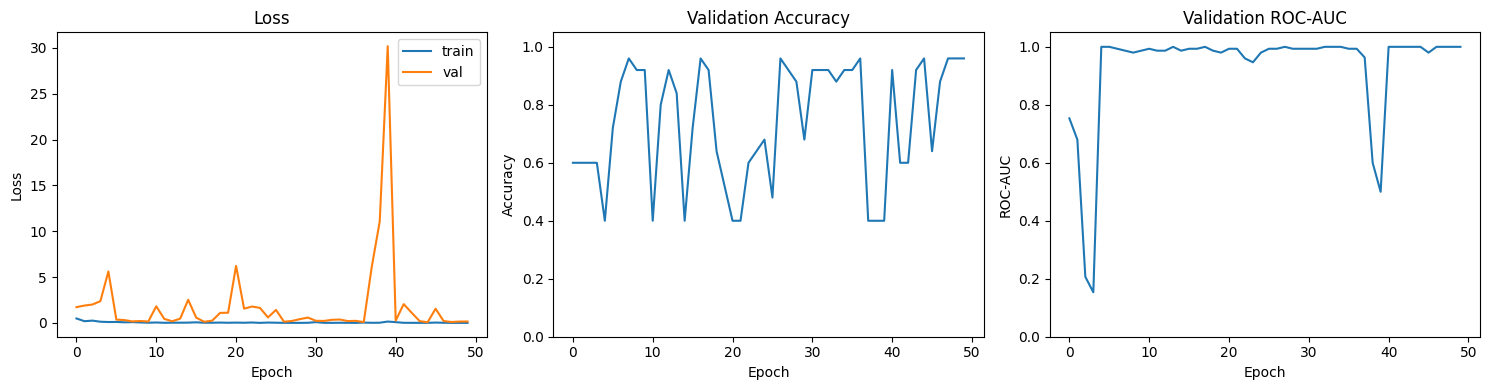

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(history["val_accuracy"], label="accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].set_ylim([0, 1.05])

axes[2].plot(history["val_roc_auc"], label="ROC-AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("Validation ROC-AUC")
axes[2].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 9. Save Artifacts

In [16]:
# Save final model
torch.save(model.state_dict(), os.path.join(run_dir, "final_model.pt"))

# Save training curves plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(history["val_accuracy"]); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy"); axes[1].set_ylim([0, 1.05])
axes[2].plot(history["val_roc_auc"]); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("Validation ROC-AUC"); axes[2].set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "training_curves.png"), dpi=150)
plt.close()

# Save history as CSV
with open(os.path.join(run_dir, "history.csv"), "w") as f:
    f.write("epoch,train_loss,val_loss,val_accuracy,val_roc_auc,val_f1\n")
    for i in range(len(history["train_loss"])):
        f.write(
            f"{i+1},{history['train_loss'][i]:.6f},{history['val_loss'][i]:.6f},"
            f"{history['val_accuracy'][i]:.6f},{history['val_roc_auc'][i]:.6f},"
            f"{history['val_f1'][i]:.6f}\n"
        )

print(f"All artifacts saved to: {run_dir}")

All artifacts saved to: /pub/scratch/sdeheredia/Coyote/examples/ml_deep_bitstream_inspection/datasets/full_dataset_it1/ml_baseline/runs/resnet18_ro4000_ep50
